<a href="https://colab.research.google.com/github/MikeStork/CyfrowePrzetwarzanieSygnalow/blob/main/pierwsze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Importy
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import butter, filtfilt, freqz, detrend

In [ ]:
# @title Załadowanie Pliku
def load_ecg(filename):
    data = np.loadtxt(filename)
    return data

In [ ]:
# @title Wybranie zakresu kanałów
def get_selected_channels(channel_count):
    user_input = input("Wybierz kanały (np. 0-2 lub 1,3,5): ")
    selected_channels = []

    for part in user_input.split(','):
        if '-' in part:
            start, end = map(int, part.split('-'))
            if start > end:
              start, end = end, start
            selected_channels.extend(range(start, end + 1))
        else:
            selected_channels.append(int(part))

    selected_channels = sorted(set(filter(lambda x: 0 <= x < channel_count, selected_channels)))
    return selected_channels

In [ ]:
# @title Generowanie i wyświetlenie wykresu normalnego
def plot_normal(val1, val2, xlabel, ylabel, title, labelPlot):
    plt.figure(figsize=(skalaWykresX, skalaWykresY))
    plt.plot(val1, val2, label=labelPlot)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    #plt.yscale('log')
    plt.show()

In [ ]:
# @title Generowanie i wyświetlenie wykresu EKG
def plot_ecg(time, signal, channels, start_idx, end_idx):

    if channels != 1:
      for ch in channels:
        plt.plot(time[start_idx:end_idx], signal[start_idx:end_idx, ch], label=f'EKG Signal {ch+1}')
    else:
      plt.plot(time[start_idx:end_idx], signal[start_idx:end_idx], label='EKG Signal 1')

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('EKG Signal Visualization')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# @title Zapis do pliku
def save_segment(data, fs, filename, start_time, duration, time_col=False):
    start_idx = int(start_time * fs)
    end_idx = int((start_time + duration) * fs)
    segment = data[start_idx:end_idx] if not time_col else data[start_idx:end_idx, :]
    np.savetxt(filename, segment, delimiter=',')
    print(f'Saved segment to {filename}')

In [ ]:
# @title Główny program
def main(data, fs, start_time=0, duration=1, time_col=False):
    # Ustawienie osi czasu i sygnału
    # Dla nowych danych mamy tylko jedną kolumnę, więc generujemy oś czasu
    if time_col:
        # (Nie będzie używane, gdyż plik ma tylko jedną kolumnę)
        time = data[:, 0]
        signal = data[:, 1]
    else:
        time = np.arange(len(data)) / fs
        if data.ndim == 1:
            signal = data
        else:
            # W przypadku, gdyby plik miał więcej niż jedną kolumnę, wybieramy pierwszą
            signal = data[:, 0]

    # Wyznaczamy indeksy segmentu na podstawie czasu
    start_idx = int(start_time * fs)
    end_idx = int((start_time + duration) * fs)

    # Wybieramy segment sygnału oraz odpowiadającą mu oś czasu
    segment = signal[start_idx:end_idx]
    time_segment = time[start_idx:end_idx]

    # Obliczamy FFT dla wybranego segmentu
    n_segment = len(segment)
    fft_segment = np.fft.fft(segment)
    frequencies = np.fft.fftfreq(n_segment, d=1/fs)

    # Bierzemy tylko dodatnie częstotliwości
    mask = frequencies >= 0
    amplitude_spectrum = np.abs(fft_segment)[mask] / n_segment  # Normalizacja przez liczbę próbek

    # Obliczamy odwrotną FFT
    inverse_fft_segment = np.fft.ifft(fft_segment)

    # Wizualizacja w dziedzinie czasu – cały sygnał z nałożonym segmentem (możesz dostosować funkcję plot_ecg)
    plot_ecg(time, signal, 1, start_idx, end_idx)

    # Wizualizacja widma FFT segmentu
    plot_normal(frequencies[mask], amplitude_spectrum, 'Frequency (Hz)', 'Amplitude',
                'Frequency Domain Visualization', 'Fourier')

    # Wizualizacja odtworzonego segmentu po IFFT
    plot_normal(time_segment, np.real(inverse_fft_segment), 'Time (s)', 'Amplitude',
                'EKG Signal Visualization IFFT', 'EKG Signal IFFT')

    difference = np.real(inverse_fft_segment) - segment
    print(f'Maximum difference: {np.max(np.abs(difference))}')

Czas trwania pliku: 1300.0 s
Wpisz czas startu: 0
Wpisz czas końca: 2


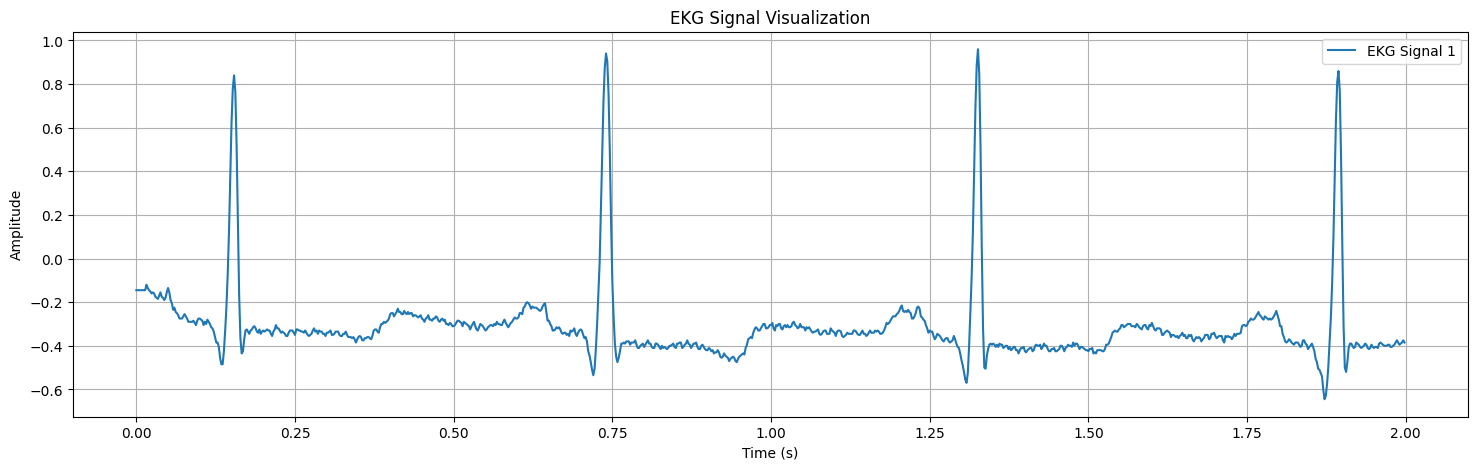

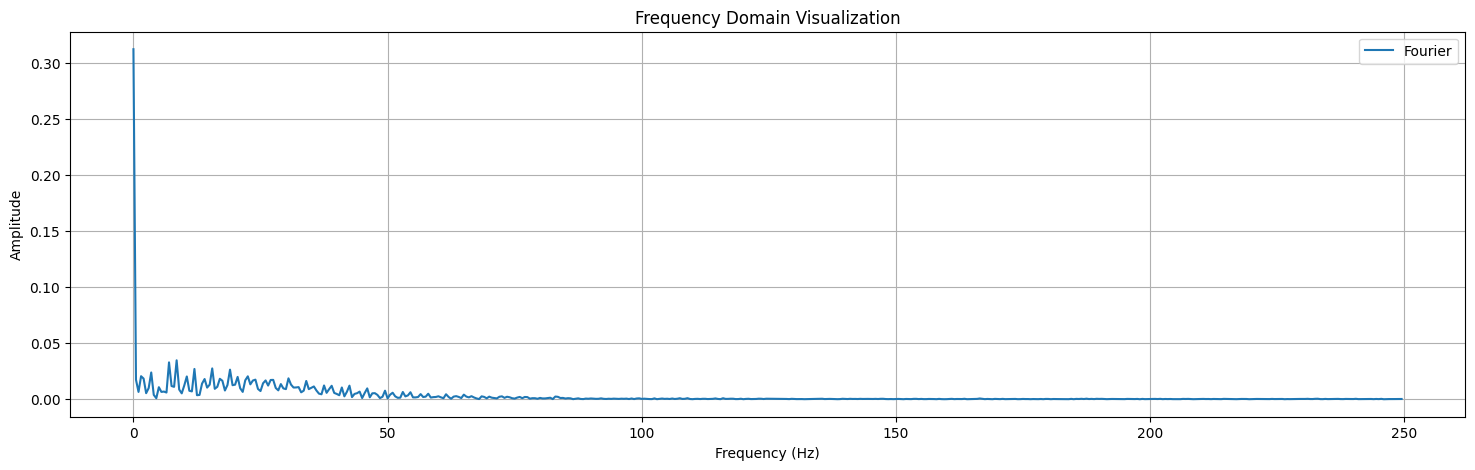

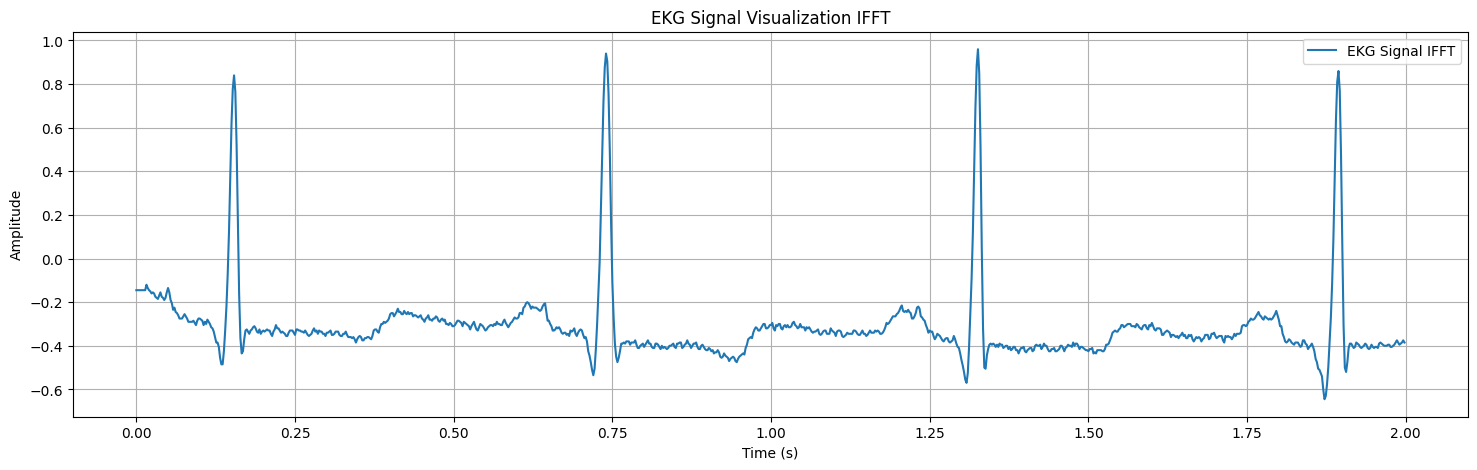

Maximum difference: 4.440892098500626e-16
Saved segment to ekg_segment.csv


In [ ]:
# @title Część 1: Analiza fragmentu sygnału EKG z użyciem FFT
# @markdown Wczytywany jest sygnał EKG z pliku tekstowego, po czym użytkownik wybiera interesujący go fragment (czas startu i czas trwania). Ten fragment jest przekształcany do dziedziny częstotliwości za pomocą FFT oraz zrekonstruowany przy użyciu IFFT. Rysowane są wykresy sygnału, jego widma oraz zrekonstruowanej wersji.

# @markdown **Cel**:
# @markdown Zobaczyć, jak transformata Fouriera przekształca sygnał do widma oraz czy sygnał można odzyskać przez IFFT.
# SETUP
filename = 'ekg100.txt'  # Plik zawiera tylko jedną kolumnę z amplitudami
savename = 'ekg_segment.csv'
time_col = False  # Brak kolumny z czasem – generujemy oś czasu

fs = 500  # Częstotliwość próbkowania (Hz)

skalaWykresX = 18
skalaWykresY = 5

plt.figure(figsize=(skalaWykresX, skalaWykresY))

# WYWOLANIE
data = load_ecg(filename)

total_time = len(data) / fs  # Całkowity czas trwania sygnału
print(f"Czas trwania pliku: {total_time} s")

# Pobieramy dane wejściowe od użytkownika
start_time = float(input("Wpisz czas startu: "))
duration = float(input("Wpisz czas końca: "))

if start_time > duration:
    start_time, duration = duration, start_time

main(data, fs, start_time, duration, time_col)
save_segment(data, fs, savename, start_time=1, duration=2)


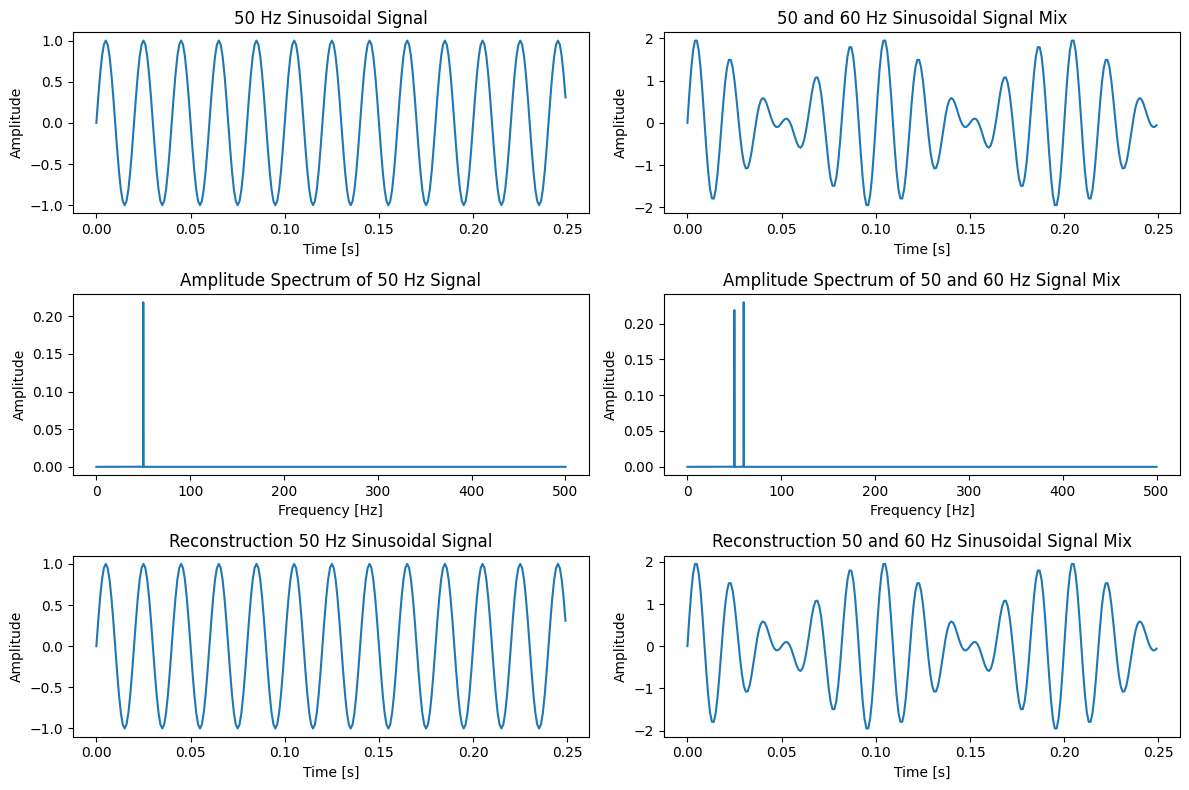

In [ ]:
# @title Część 2: Sygnały sinusoidalne i wpływ częstotliwości próbkowania
# @markdown Generowane są sztuczne sygnały sinusoidalne 50 Hz i 50+60 Hz. Następnie wykonywana jest analiza FFT i IFFT dla różnych częstotliwości próbkowania. Rysowane są wykresy sygnałów oraz ich widm i zrekonstruowanych postaci.

# @markdown **Cel**:
# @markdown Zrozumienie działania FFT na sygnałach o znanych częstotliwościach i wpływu częstotliwości próbkowania.
# Parametry
fs = 1000 # @param {"type":"integer"}
f1 = 50
f2 = 60
T = 1 / fs
N = 65536
t = np.linspace(0, (N - 1) * T, N)
frequencies = np.fft.fftfreq(N, T)
positive_frequencies = frequencies[:N // 2]

# Generowanie sygnału sinusoidalnego
signal_50Hz = np.sin(2 * np.pi * f1 * t)
fft_signal_50Hz = np.fft.fft(signal_50Hz)
ifft_signal_50Hz = np.fft.ifft(fft_signal_50Hz)

# Sygnał mieszany
signal_50Hz60Hz = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
fft_signal_50Hz60Hz = np.fft.fft(signal_50Hz60Hz)
ifft_signal_50Hz60Hz = np.fft.ifft(fft_signal_50Hz60Hz)

# Do wykresów
amplitude_spectrum_50Hz = (np.abs(fft_signal_50Hz[:N // 2]) / N) ** 2
amplitude_spectrum_50Hz60Hz = (np.abs(fft_signal_50Hz60Hz[:N // 2]) / N) ** 2

# Zmiana częstotliwości próbkowania
fs_new = 500
T_new = 1 / fs_new
N_new = 65536
t_new = np.linspace(0, (N_new - 1) * T_new, N_new)
frequencies_new = np.fft.fftfreq(N_new, T_new)
positive_frequencies_new = frequencies_new[:N_new // 2]

new_signal_50Hz60Hz = np.sin(2 * np.pi * f1 * t_new) + np.sin(2 * np.pi * f2 * t_new)
new_fft_singal_50Hz60Hz = np.fft.fft(new_signal_50Hz60Hz)
new_ifft_singal_50Hz60Hz = np.fft.ifft(new_fft_singal_50Hz60Hz)

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 8))

# Plot 50 Hz sinusoidal signal
axs[0, 0].plot(t[:250], signal_50Hz[:250])
axs[0, 0].set_title("50 Hz Sinusoidal Signal")
axs[0, 0].set_xlabel("Time [s]")
axs[0, 0].set_ylabel("Amplitude")

# Plot 50 and 60 Hz sinusoidal signal mix
axs[0, 1].plot(t[:250], signal_50Hz60Hz[:250])
axs[0, 1].set_title("50 and 60 Hz Sinusoidal Signal Mix")
axs[0, 1].set_xlabel("Time [s]")
axs[0, 1].set_ylabel("Amplitude")

# Plot amplitude spectrum of 50 Hz signal
axs[1, 0].plot(positive_frequencies, amplitude_spectrum_50Hz)
axs[1, 0].set_title("Amplitude Spectrum of 50 Hz Signal")
axs[1, 0].set_xlabel("Frequency [Hz]")
axs[1, 0].set_ylabel("Amplitude")

# Plot amplitude spectrum of 50 and 60 Hz signal mix
axs[1, 1].plot(positive_frequencies, amplitude_spectrum_50Hz60Hz)
axs[1, 1].set_title("Amplitude Spectrum of 50 and 60 Hz Signal Mix")
axs[1, 1].set_xlabel("Frequency [Hz]")
axs[1, 1].set_ylabel("Amplitude")

# Plot 50 Hz sinusoidal signal
axs[2, 0].plot(t[:250], np.real(ifft_signal_50Hz[:250]))
axs[2, 0].set_title("Reconstruction 50 Hz Sinusoidal Signal")
axs[2, 0].set_xlabel("Time [s]")
axs[2, 0].set_ylabel("Amplitude")

# Plot 50 and 60 Hz sinusoidal signal mix
axs[2, 1].plot(t[:250], np.real(ifft_signal_50Hz60Hz[:250]))
axs[2, 1].set_title("Reconstruction 50 and 60 Hz Sinusoidal Signal Mix")
axs[2, 1].set_xlabel("Time [s]")
axs[2, 1].set_ylabel("Amplitude")

# Adjust layout for better readability
plt.tight_layout()
plt.show()

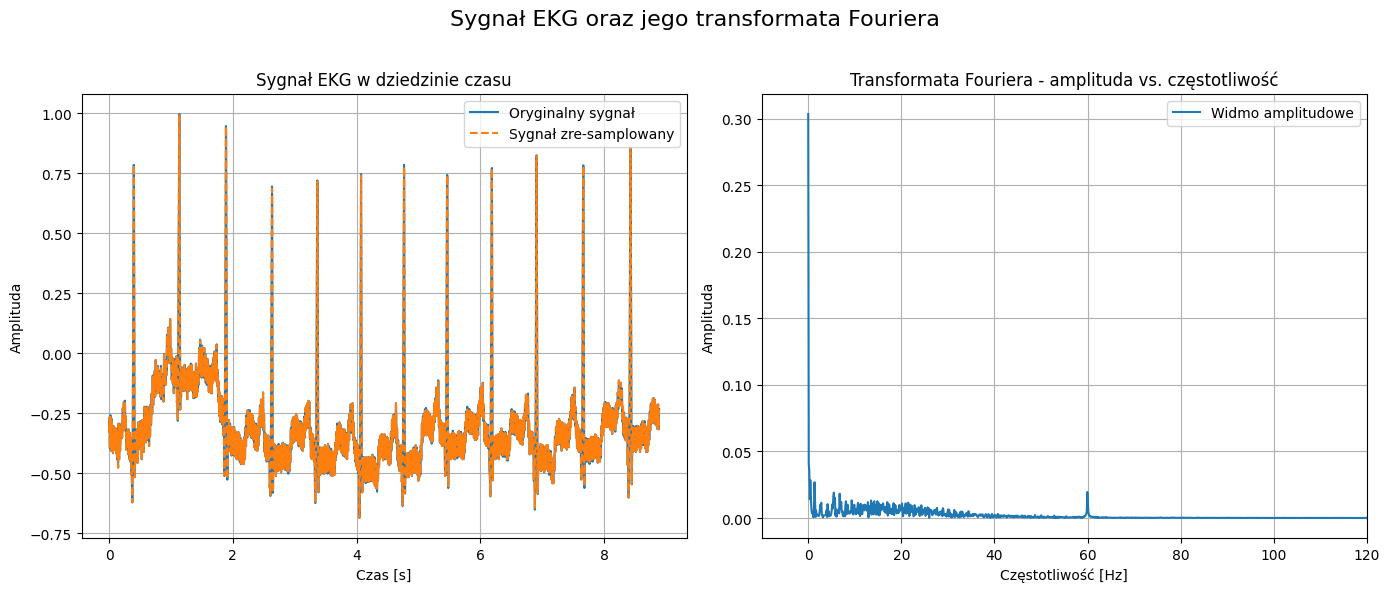

In [ ]:
# @title Część 3: Interpolacja i analiza FFT sygnału EKG
# @markdown Wczytywany sygnał EKG z nieregularną osią czasu jest interpolowany do równomiernej siatki czasowej. Następnie wykonywana jest analiza FFT i wizualizacja sygnału oryginalnego i interpolowanego.

# @markdown **Cel**:
# @markdown Przekształcenie sygnału do postaci równomiernie próbkowanej umożliwiającej analizę częstotliwościową.



import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Funkcja do wczytywania sygnału (zakładamy, że plik ma dwie kolumny: czas i sygnał)
def load_ecg(filename):
    return np.loadtxt(filename)

# Funkcja realizująca filtr dolnoprzepustowy Butterwortha (niezmieniona)
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, signal)
    return y, b, a

# ----------------------------------------------------
# Wczytanie danych
# ----------------------------------------------------
filename = 'ekg_noise.txt'
data = load_ecg(filename)
time = data[:, 0]          # kolumna z czasem
ekg_signal = data[:, 1]      # kolumna z sygnałem EKG

# ----------------------------------------------------
# Re-samplowanie do równomiernej siatki czasowej
# ----------------------------------------------------
fs = 1000  # zadana częstotliwość próbkowania (Hz)
# Utwórz równomierną siatkę czasową od początku do końca sygnału
time_uniform = np.arange(time[0], time[-1], 1/fs)
# Interpolacja oryginalnego sygnału na równomierną siatkę
ekg_uniform = np.interp(time_uniform, time, ekg_signal)

n = len(ekg_uniform)  # liczba próbek po interpolacji

# ----------------------------------------------------
# Transformata Fouriera (FFT) sygnału zre-samplowanego
# ----------------------------------------------------
fft_vals = np.fft.fft(ekg_uniform)
amplitude_spectrum = (np.abs(fft_vals) / n)
frequencies = np.fft.fftfreq(n, 1/fs)

# Wyświetlamy tylko dodatnie częstotliwości:
idx = frequencies >= 0
positive_freqs = frequencies[idx]
positive_amplitude = amplitude_spectrum[idx]

# ----------------------------------------------------
# Wizualizacja
# ----------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sygnał EKG oraz jego transformata Fouriera', fontsize=16)

# (1) Sygnał w dziedzinie czasu
axs[0].plot(time, ekg_signal, label='Oryginalny sygnał')
axs[0].plot(time_uniform, ekg_uniform, label='Sygnał zre-samplowany', linestyle='--')
axs[0].set_title('Sygnał EKG w dziedzinie czasu')
axs[0].set_xlabel('Czas [s]')
axs[0].set_ylabel('Amplituda')
axs[0].grid(True)
axs[0].legend()

# (2) Widmo amplitudowe (FFT)
axs[1].plot(positive_freqs, positive_amplitude, label='Widmo amplitudowe')
axs[1].set_title('Transformata Fouriera - amplituda vs. częstotliwość')
axs[1].set_xlabel('Częstotliwość [Hz]')
axs[1].set_ylabel('Amplituda')
axs[1].grid(True)
axs[1].legend()
axs[1].set_xlim(-10, 120)  # Ograniczenie wykresu do 120 Hz

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


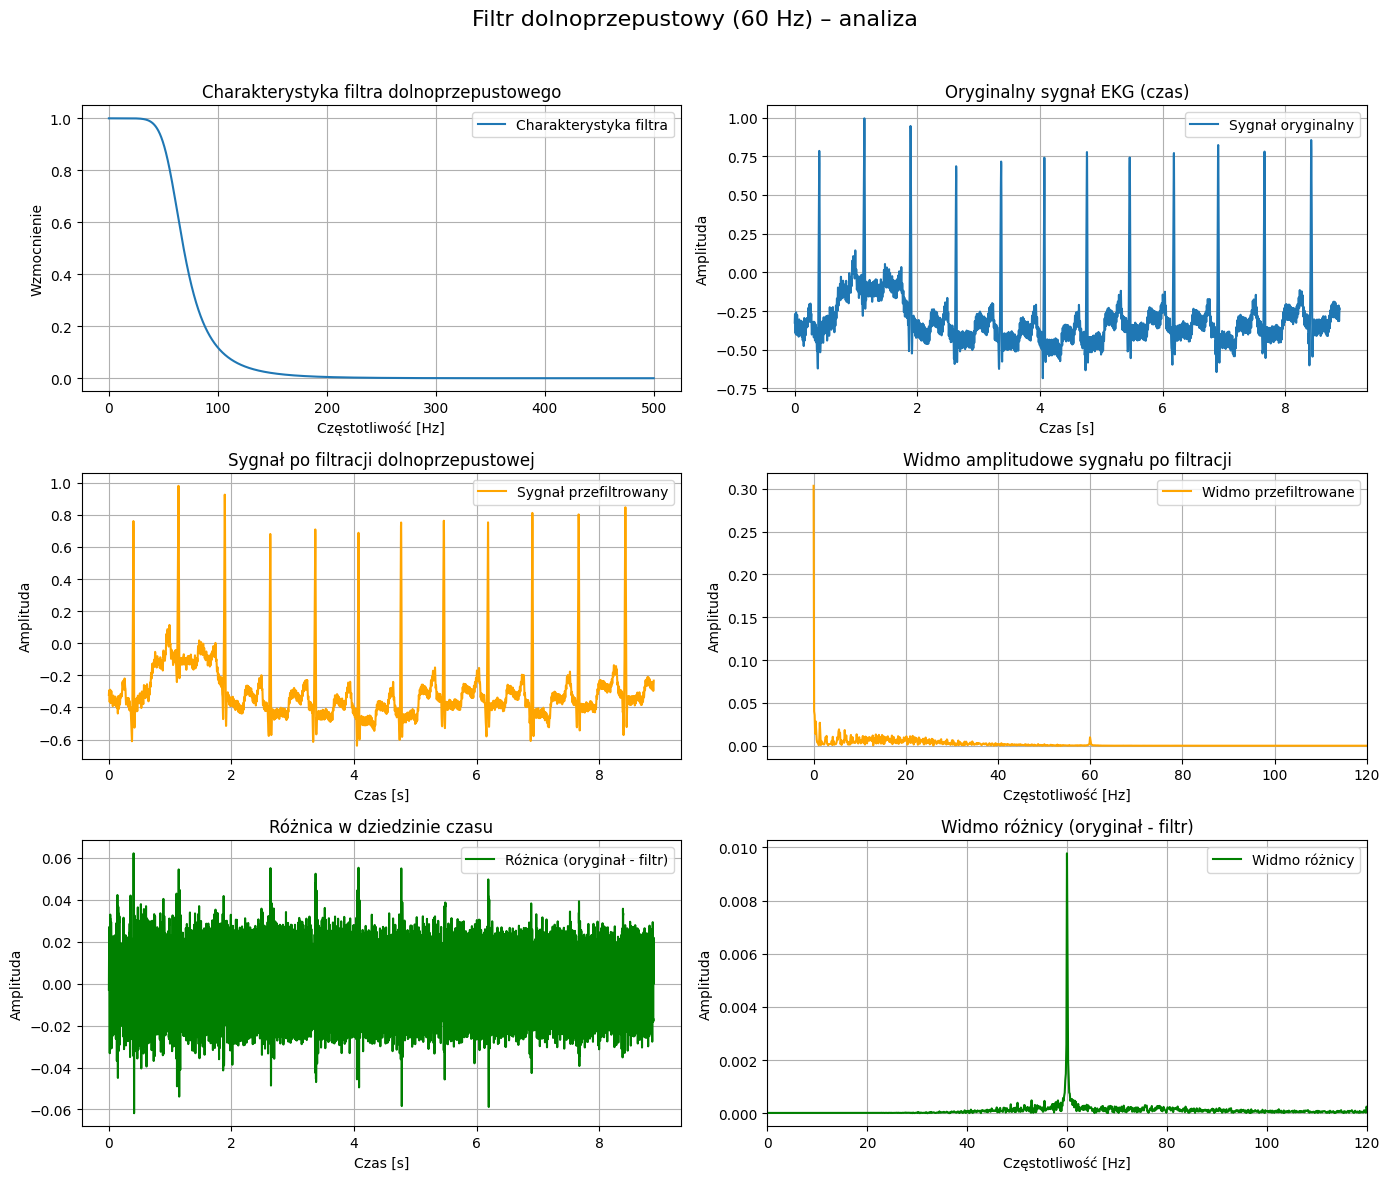

In [ ]:
# @title Część 4: Filtracja dolnoprzepustowa (60 Hz)
# @markdown Na zinterpolowanym sygnale EKG stosowany jest filtr dolnoprzepustowy Butterwortha. Przedstawiona jest jego charakterystyka, sygnał przed i po filtracji oraz ich FFT i różnice.

# @markdown **Cel**:
# @markdown Usunięcie zakłóceń powyżej 60 Hz i analiza wpływu filtracji na widmo.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

# Funkcja wczytująca dane; zakładamy, że plik ma dwie kolumny: czas, sygnał
def load_ecg(filename):
    return np.loadtxt(filename)

# Funkcja realizująca filtr dolnoprzepustowy Butterwortha
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered = filtfilt(b, a, signal)
    return filtered, b, a

# ----------------------------------------------------
# Wczytanie danych
# ----------------------------------------------------
filename = 'ekg_noise.txt'
data = load_ecg(filename)
time = data[:, 0]        # czasy (mogą być nieregularne)
ekg_signal = data[:, 1]    # sygnał EKG

fs = 1000  # zadana częstotliwość próbkowania (Hz)
# Utwórz równomierną siatkę czasową od początku do końca sygnału
time_uniform = np.arange(time[0], time[-1], 1/fs)
# Interpolacja sygnału na równomierną siatkę
ekg_uniform = np.interp(time_uniform, time, ekg_signal)
n = len(ekg_uniform)

# ----------------------------------------------------
# Filtracja dolnoprzepustowa (60 Hz)
# ----------------------------------------------------
cutoff_low = 60
filtered_signal, b_low, a_low = butter_lowpass_filter(ekg_uniform, cutoff_low, fs)

# ----------------------------------------------------
# Charakterystyka filtra (częstotliwość - wzmocnienie)
# ----------------------------------------------------
w, h = freqz(b_low, a_low, worN=8000)
freq_response = w * fs / (2 * np.pi)

# ----------------------------------------------------
# Transformata Fouriera sygnałów
# ----------------------------------------------------
fft_original = np.fft.fft(ekg_uniform)
fft_filtered = np.fft.fft(filtered_signal)
fft_diff = np.fft.fft(ekg_uniform - filtered_signal)

freq = np.fft.fftfreq(n, 1/fs)
# Wyświetlamy tylko dodatnie częstotliwości:
positive_freq = freq[:n//2]
amp_original = np.abs(fft_original)[:n//2] / n
amp_filtered = np.abs(fft_filtered)[:n//2] / n
amp_diff = np.abs(fft_diff)[:n//2] / n

# ----------------------------------------------------
# Wizualizacja – tworzymy 3x2 wykresy
# ----------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Filtr dolnoprzepustowy (60 Hz) – analiza', fontsize=16)

# (1) Charakterystyka filtra (zależność tłumienia od częstotliwości)
axs[0, 0].plot(freq_response, np.abs(h), label='Charakterystyka filtra')
axs[0, 0].set_title('Charakterystyka filtra dolnoprzepustowego')
axs[0, 0].set_xlabel('Częstotliwość [Hz]')
axs[0, 0].set_ylabel('Wzmocnienie')
axs[0, 0].grid(True)
axs[0, 0].legend()

# (2) Oryginalny sygnał EKG w dziedzinie czasu (po interpolacji)
axs[0, 1].plot(time_uniform, ekg_uniform, label='Sygnał oryginalny')
axs[0, 1].set_title('Oryginalny sygnał EKG (czas)')
axs[0, 1].set_xlabel('Czas [s]')
axs[0, 1].set_ylabel('Amplituda')
axs[0, 1].grid(True)
axs[0, 1].legend()

# (3) Sygnał po filtracji dolnoprzepustowej (czas)
axs[1, 0].plot(time_uniform, filtered_signal, color='orange', label='Sygnał przefiltrowany')
axs[1, 0].set_title('Sygnał po filtracji dolnoprzepustowej')
axs[1, 0].set_xlabel('Czas [s]')
axs[1, 0].set_ylabel('Amplituda')
axs[1, 0].grid(True)
axs[1, 0].legend()

# (4) Widmo amplitudowe sygnału po filtracji
axs[1, 1].plot(positive_freq, amp_filtered, color='orange', label='Widmo przefiltrowane')
axs[1, 1].set_title('Widmo amplitudowe sygnału po filtracji')
axs[1, 1].set_xlabel('Częstotliwość [Hz]')
axs[1, 1].set_ylabel('Amplituda')
axs[1, 1].grid(True)
axs[1, 1].legend()
axs[1, 1].set_xlim(-10, 120)

# (5) Różnica między sygnałem oryginalnym a przefiltrowanym (czas)
axs[2, 0].plot(time_uniform, ekg_uniform - filtered_signal, color='green', label='Różnica (oryginał - filtr)')
axs[2, 0].set_title('Różnica w dziedzinie czasu')
axs[2, 0].set_xlabel('Czas [s]')
axs[2, 0].set_ylabel('Amplituda')
axs[2, 0].grid(True)
axs[2, 0].legend()

# (6) Widmo różnicy (oryginał - filtr)
axs[2, 1].plot(positive_freq, amp_diff, color='green', label='Widmo różnicy')
axs[2, 1].set_title('Widmo różnicy (oryginał - filtr)')
axs[2, 1].set_xlabel('Częstotliwość [Hz]')
axs[2, 1].set_ylabel('Amplituda')
axs[2, 1].grid(True)
axs[2, 1].legend()
axs[2, 1].set_xlim(0, 120)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


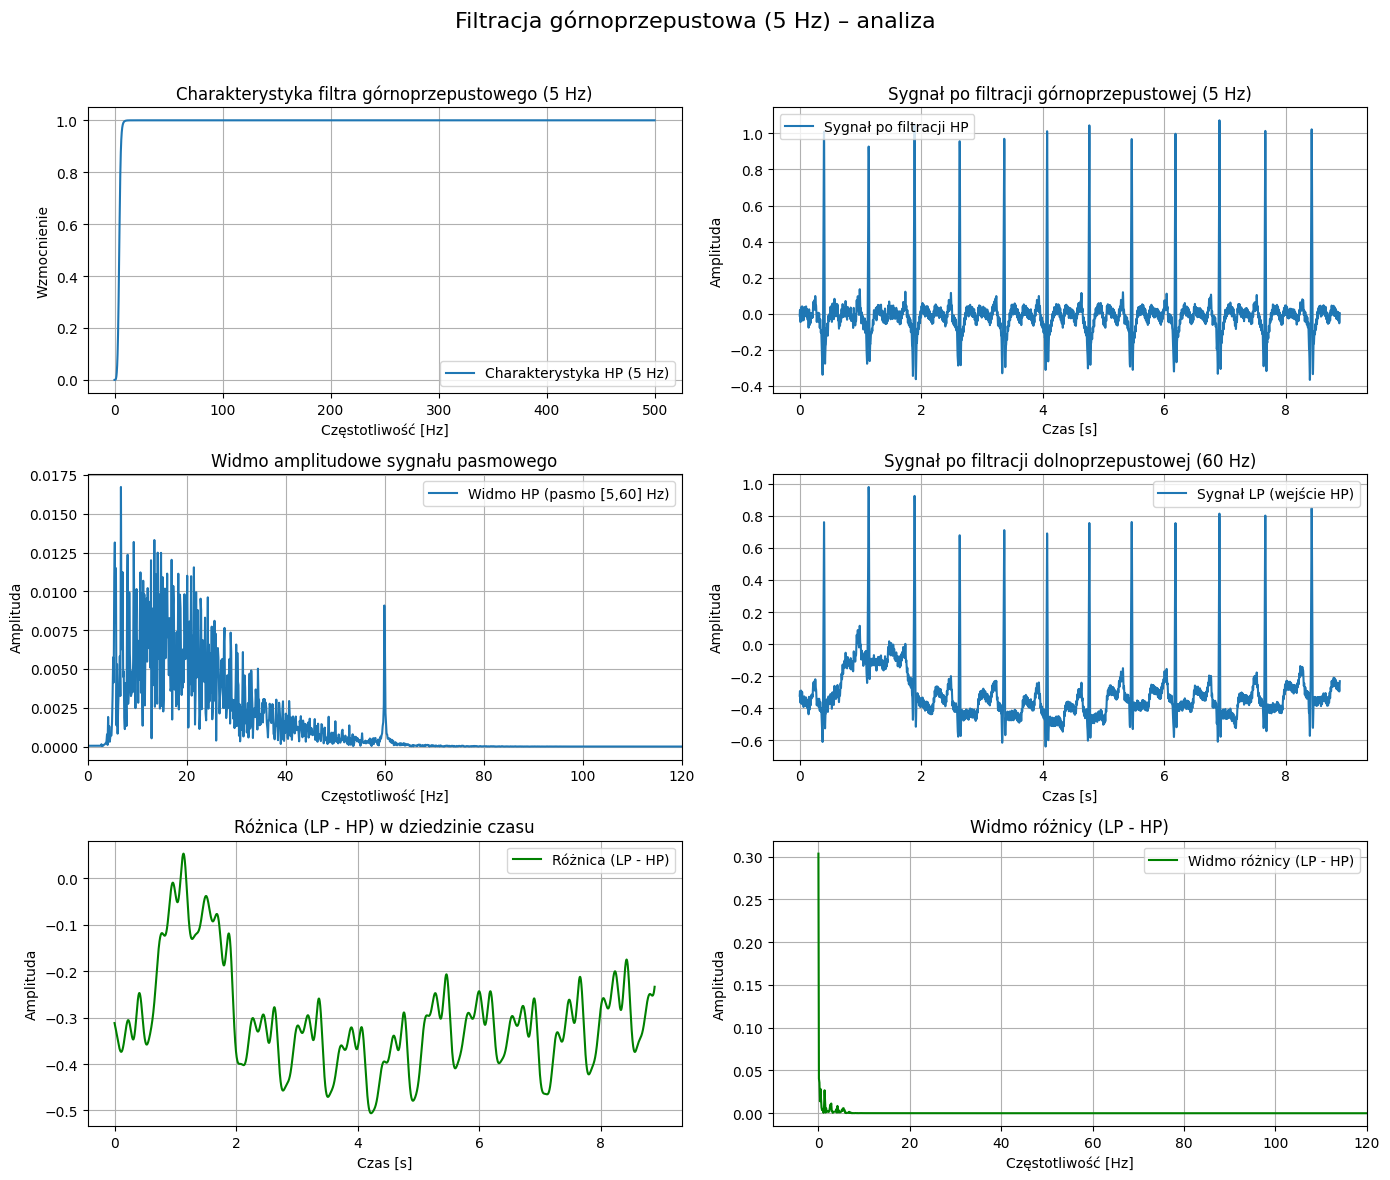

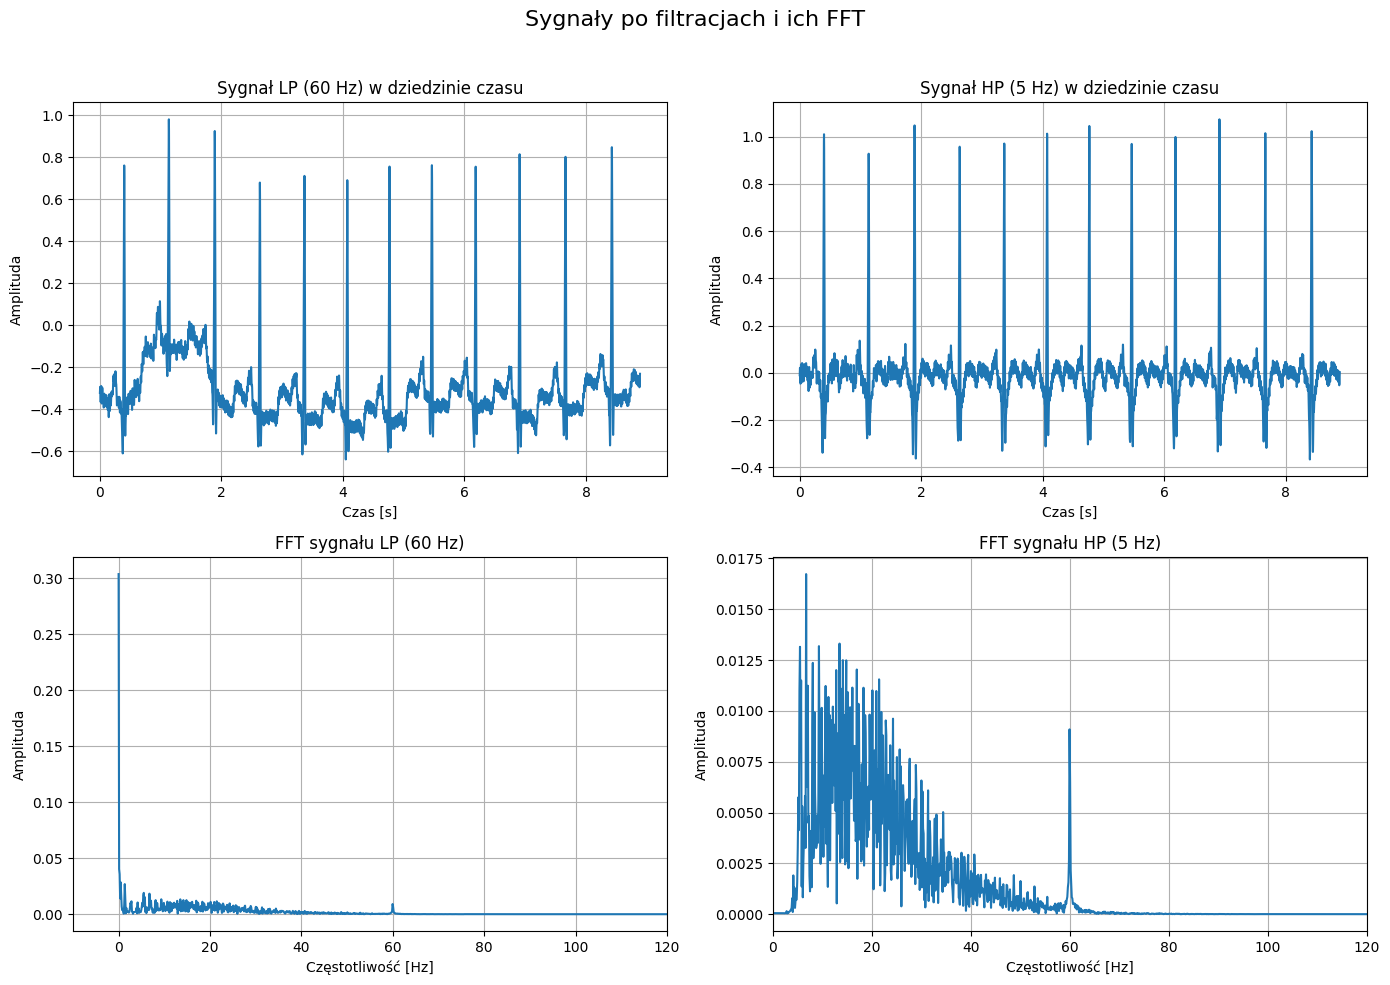

In [ ]:
# @title Część 5: Filtracja pasmowa (5–60 Hz)
# @markdown Sygnał EKG najpierw przechodzi przez filtr dolnoprzepustowy (60 Hz), a potem przez filtr górnoprzepustowy (5 Hz), tworząc filtrację pasmową. Pokazane są wszystkie etapy przetwarzania oraz widma.

# @markdown **Cel**:
# @markdown Wydzielenie istotnego pasma sygnału EKG, gdzie najczęściej znajdują się jego cechy diagnostyczne.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

# ----------------------------------------------------
# Funkcje pomocnicze
# ----------------------------------------------------
def load_ecg(filename):
    """
    Wczytuje dane z pliku tekstowego. Zakładamy, że plik ma dwie kolumny:
    1) czas (może być nieregularny),
    2) wartość sygnału (amplituda).
    """
    return np.loadtxt(filename)

def butter_lowpass_filter(signal, cutoff, fs, order=4):
    """
    Filtr dolnoprzepustowy Butterwortha.
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, signal)
    return y, b, a

def butter_highpass_filter(signal, cutoff, fs, order=4):
    """
    Filtr górnoprzepustowy Butterwortha.
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, signal)
    return y, b, a

# ----------------------------------------------------
# Wczytanie danych
# ----------------------------------------------------
filename = 'ekg_noise.txt'
data = load_ecg(filename)

# Upewnij się, że dane są posortowane wg czasu
data = data[np.argsort(data[:, 0])]
time_original = data[:, 0]
ekg_original = data[:, 1]

# ----------------------------------------------------
# Ustawiamy docelową częstotliwość próbkowania (Hz)
# ----------------------------------------------------
fs_target = 1000.0

# Tworzymy równomierną siatkę czasową od t_min do t_max
t_min, t_max = time_original[0], time_original[-1]
duration = t_max - t_min
n_target = int(duration * fs_target) + 1

time_uniform = np.linspace(t_min, t_max, n_target)
ekg_uniform = np.interp(time_uniform, time_original, ekg_original)

# Rzeczywista częstotliwość próbkowania po interpolacji
fs_effective = (n_target - 1) / duration

# ----------------------------------------------------
# Filtracja pasmowa [5, 60] Hz:
# 1) dolnoprzepustowy (60 Hz)
# 2) górnoprzepustowy (5 Hz)
# ----------------------------------------------------
cutoff_low = 60.0
cutoff_high = 5.0

filtered_low, b_low, a_low = butter_lowpass_filter(ekg_uniform, cutoff_low, fs_effective)
filtered_high, b_high, a_high = butter_highpass_filter(filtered_low, cutoff_high, fs_effective)

# Różnica między sygnałem po LP a sygnałem po HP
diff_signal = filtered_low - filtered_high

# ----------------------------------------------------
# Obliczenia FFT
# ----------------------------------------------------
n = len(ekg_uniform)

# Oś częstotliwości
freq = np.fft.fftfreq(n, d=1/fs_effective)
idx_positive = freq >= 0
freq_pos = freq[idx_positive]

# FFT sygnału po filtracji dolnoprzepustowej (LP)
fft_low = np.fft.fft(filtered_low)
amp_low = np.abs(fft_low)[idx_positive] / n

# FFT sygnału po filtracji górnoprzepustowej (HP, wynik pasmowy)
fft_high = np.fft.fft(filtered_high)
amp_high = np.abs(fft_high)[idx_positive] / n

# FFT różnicy (LP - HP)
fft_diff = np.fft.fft(diff_signal)
amp_diff = np.abs(fft_diff)[idx_positive] / n

# ----------------------------------------------------
# Charakterystyka filtra górnoprzepustowego (5 Hz)
# ----------------------------------------------------
w_hp, h_hp = freqz(b_high, a_high, worN=8000)
freq_hp = w_hp * fs_effective / (2.0 * np.pi)

# ----------------------------------------------------
# Wizualizacja – pierwsza figura z analizą dotychczasową
# ----------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Filtracja górnoprzepustowa (5 Hz) – analiza', fontsize=16)

# (1) Charakterystyka filtra górnoprzepustowego
axs[0, 0].plot(freq_hp, np.abs(h_hp), label='Charakterystyka HP (5 Hz)')
axs[0, 0].set_title('Charakterystyka filtra górnoprzepustowego (5 Hz)')
axs[0, 0].set_xlabel('Częstotliwość [Hz]')
axs[0, 0].set_ylabel('Wzmocnienie')
axs[0, 0].grid(True)
axs[0, 0].legend()

# (2) Sygnał po filtracji górnoprzepustowej (HP)
axs[0, 1].plot(time_uniform, filtered_high, label='Sygnał po filtracji HP')
axs[0, 1].set_title('Sygnał po filtracji górnoprzepustowej (5 Hz)')
axs[0, 1].set_xlabel('Czas [s]')
axs[0, 1].set_ylabel('Amplituda')
axs[0, 1].grid(True)
axs[0, 1].legend()

# (3) Widmo amplitudowe sygnału po filtracji górnoprzepustowej
axs[1, 0].plot(freq_pos, amp_high, label='Widmo HP (pasmo [5,60] Hz)')
axs[1, 0].set_title('Widmo amplitudowe sygnału pasmowego')
axs[1, 0].set_xlabel('Częstotliwość [Hz]')
axs[1, 0].set_ylabel('Amplituda')
axs[1, 0].grid(True)
axs[1, 0].legend()
axs[1, 0].set_xlim(0, 120)

# (4) Sygnał po filtracji dolnoprzepustowej (LP) – wejście do HP
axs[1, 1].plot(time_uniform, filtered_low, label='Sygnał LP (wejście HP)')
axs[1, 1].set_title('Sygnał po filtracji dolnoprzepustowej (60 Hz)')
axs[1, 1].set_xlabel('Czas [s]')
axs[1, 1].set_ylabel('Amplituda')
axs[1, 1].grid(True)
axs[1, 1].legend()

# (5) Różnica (LP - HP) w dziedzinie czasu
axs[2, 0].plot(time_uniform, diff_signal, color='green', label='Różnica (LP - HP)')
axs[2, 0].set_title('Różnica (LP - HP) w dziedzinie czasu')
axs[2, 0].set_xlabel('Czas [s]')
axs[2, 0].set_ylabel('Amplituda')
axs[2, 0].grid(True)
axs[2, 0].legend()

# (6) Widmo amplitudowe różnicy (LP - HP)
axs[2, 1].plot(freq_pos, amp_diff, color='green', label='Widmo różnicy (LP - HP)')
axs[2, 1].set_title('Widmo różnicy (LP - HP)')
axs[2, 1].set_xlabel('Częstotliwość [Hz]')
axs[2, 1].set_ylabel('Amplituda')
axs[2, 1].grid(True)
axs[2, 1].legend()
axs[2, 1].set_xlim(-10, 120)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ----------------------------------------------------
# Dodatkowa wizualizacja – sygnały po obu filtracjach i ich FFT
# ----------------------------------------------------
fig2, axs2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Sygnały po filtracjach i ich FFT', fontsize=16)

# Sygnał po filtracji dolnoprzepustowej (LP) w dziedzinie czasu
axs2[0, 0].plot(time_uniform, filtered_low)
axs2[0, 0].set_title('Sygnał LP (60 Hz) w dziedzinie czasu')
axs2[0, 0].set_xlabel('Czas [s]')
axs2[0, 0].set_ylabel('Amplituda')
axs2[0, 0].grid(True)

# Sygnał po filtracji górnoprzepustowej (HP) w dziedzinie czasu
axs2[0, 1].plot(time_uniform, filtered_high)
axs2[0, 1].set_title('Sygnał HP (5 Hz) w dziedzinie czasu')
axs2[0, 1].set_xlabel('Czas [s]')
axs2[0, 1].set_ylabel('Amplituda')
axs2[0, 1].grid(True)

# FFT sygnału LP
axs2[1, 0].plot(freq_pos, amp_low)
axs2[1, 0].set_title('FFT sygnału LP (60 Hz)')
axs2[1, 0].set_xlabel('Częstotliwość [Hz]')
axs2[1, 0].set_ylabel('Amplituda')
axs2[1, 0].grid(True)
axs2[1, 0].set_xlim(-10, 120)

# FFT sygnału HP
axs2[1, 1].plot(freq_pos, amp_high)
axs2[1, 1].set_title('FFT sygnału HP (5 Hz)')
axs2[1, 1].set_xlabel('Częstotliwość [Hz]')
axs2[1, 1].set_ylabel('Amplituda')
axs2[1, 1].grid(True)
axs2[1, 1].set_xlim(0, 120)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
